# 1.0 Introduction to Classification & k-Nearest Neighbors (kNN)

## 1. The Bridge: From Regression to Classification
In the previous session, you explored **Regression**—predicting continuous numeric quantities (e.g., house prices, stock values, semester GPAs).

However, in many real-world systems, the core question isn't *"How much?"*, but *"Which category?"*:
- Is this incoming email **Spam (1)** or **Legitimate (0)**?
- Is this financial transaction **Fraudulent (1)** or **Authentic (0)**?
- Will this user click to **Purchase (1)** or **Not Purchase (0)**?

This is **Classification**: mapping input features to discrete, categorical labels ($y \in \{0, 1\}$ or multi-class classes).

---

## 2. What is k-Nearest Neighbors (kNN)?
- **Core Intuition**: *"You are the average of the $k$ closest people around you."*
- To predict the class of a new query point, kNN measures the distance to all existing points in the training set, locates the $k$ nearest neighbors, and casts a **majority vote**.
- **Distance Metric**: The standard formula is **Euclidean Distance**:
  $$d(p, q) = \sqrt{\sum_{i=1}^{n} (p_i - q_i)^2}$$
- **Lazy Learner**: kNN has no explicit training phase; it stores the dataset in memory and computes predictions on the fly.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

## Step 1: Loading & Inspecting the Dataset
We use `social_network_ads.csv` to predict whether a customer will purchase a product (`Purchased`: 0 or 1) based on their `Age` and `EstimatedSalary`.

In [2]:
df = pd.read_csv('datasets/social_network_ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [3]:
print("Dataset Shape:", df.shape)
print("\nClass Distribution (Counts):")
print(df['Purchased'].value_counts())
print("\nClass Distribution (Proportion):")
print(df['Purchased'].value_counts(normalize=True).round(3))

Dataset Shape: (462, 5)

Class Distribution (Counts):
Purchased
1    239
0    223
Name: count, dtype: int64

Class Distribution (Proportion):
Purchased
1    0.517
0    0.483
Name: proportion, dtype: float64


## Step 2: Visualizing the Decision Space (2D Scatter Plot)
Let's visualize the relationship between `Age`, `EstimatedSalary`, and the outcome `Purchased`.

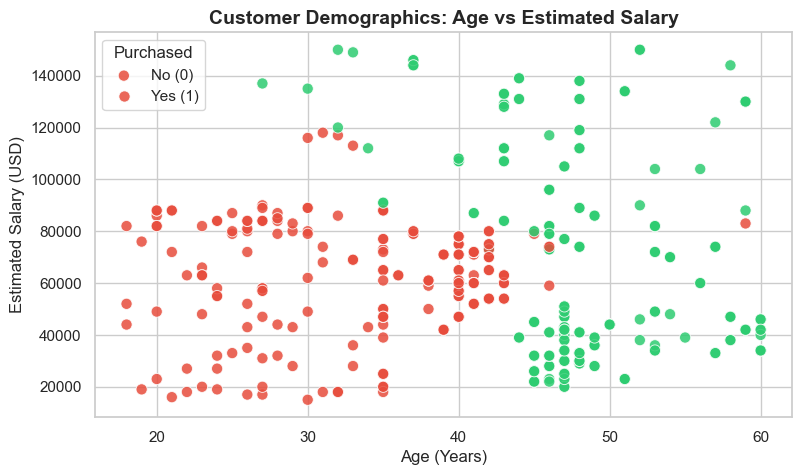

In [4]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x='Age',
    y='EstimatedSalary',
    hue='Purchased',
    palette={0: '#e74c3c', 1: '#2ecc71'},
    alpha=0.85,
    s=65
)
plt.title('Customer Demographics: Age vs Estimated Salary', fontsize=14, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Estimated Salary (USD)', fontsize=12)
plt.legend(title='Purchased', labels=['No (0)', 'Yes (1)'])
plt.show()

## Step 3: Train-Test Split & Why Feature Scaling is MANDATORY

Look closely at the numbers:
- `Age` is between **18 and 60**.
- `EstimatedSalary` is between **15,000 and 150,000**.

If we calculate Euclidean distance without scaling:
$$d = \sqrt{(Age_1 - Age_2)^2 + (Salary_1 - Salary_2)^2}$$
A difference of 10 years squared is $100$. A difference of $10,000 salary squared is $100,000,000$.
**Salary completely dominates the distance, rendering Age invisible!**

Connecting back to our **Feature Engineering** session: **Feature scaling is non-negotiable for distance-based algorithms like kNN**.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Before Scaling -> Age Mean:", round(X_train[:, 0].mean(), 1), "| Salary Mean:", round(X_train[:, 1].mean(), 1))
print("After Scaling  -> Age Mean:", round(X_train_scaled[:, 0].mean(), 1), "| Salary Mean:", round(X_train_scaled[:, 1].mean(), 1))

Before Scaling -> Age Mean: 41.0 | Salary Mean: 65054.9
After Scaling  -> Age Mean: -0.0 | Salary Mean: -0.0


## Step 4: Training the kNN Classifier
We instantiate `KNeighborsClassifier` from scikit-learn with $k=5$ neighbors and Euclidean distance (`p=2`).

In [6]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

## Step 5: Evaluating Classification Performance
Unlike regression ($R^2$, RMSE), classification evaluates discrete prediction outcomes:
1. **Confusion Matrix**: Identifies True Negatives, False Positives (Type I error), False Negatives (Type II error), and True Positives.
2. **Classification Report**: Precision (purity of positive calls), Recall (coverage of actual positives), and F1-Score (harmonic mean).

Test Accuracy: 96.55%



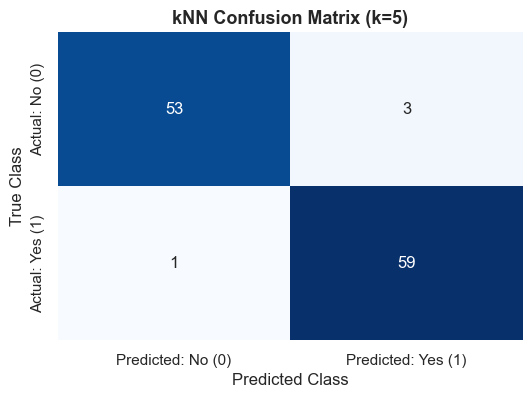

Classification Report:
                 precision    recall  f1-score   support

No Purchase (0)       0.98      0.95      0.96        56
  Purchased (1)       0.95      0.98      0.97        60

       accuracy                           0.97       116
      macro avg       0.97      0.96      0.97       116
   weighted avg       0.97      0.97      0.97       116



In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc * 100:.2f}%\n")


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted: No (0)', 'Predicted: Yes (1)'],
            yticklabels=['Actual: No (0)', 'Actual: Yes (1)'])
plt.title('kNN Confusion Matrix (k=5)', fontsize=13, fontweight='bold')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()


print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Purchase (0)', 'Purchased (1)']))

## Step 6: Visualizing the kNN Decision Boundary
Let's render the decision boundary to see how the feature space is partitioned.

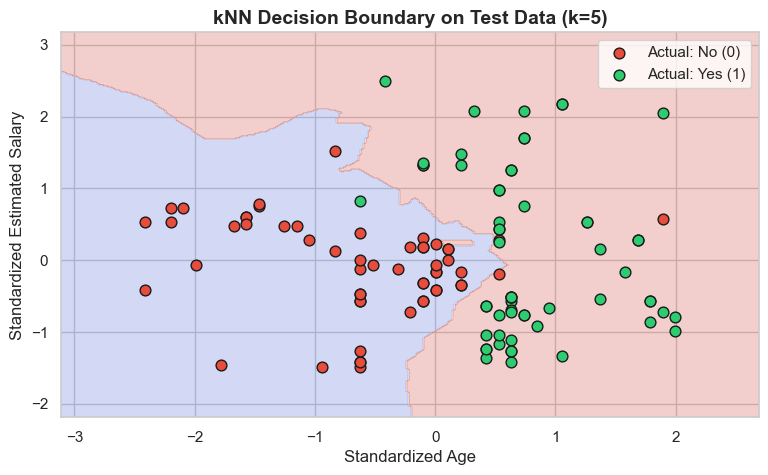

In [8]:
x_min, x_max = X_test_scaled[:, 0].min() - 0.7, X_test_scaled[:, 0].max() + 0.7
y_min, y_max = X_test_scaled[:, 1].min() - 0.7, X_test_scaled[:, 1].max() + 0.7
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))


Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)


plt.figure(figsize=(9, 5))
plt.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.coolwarm)
plt.scatter(X_test_scaled[y_test == 0, 0], X_test_scaled[y_test == 0, 1], color='#e74c3c', label='Actual: No (0)', edgecolors='k', s=60)
plt.scatter(X_test_scaled[y_test == 1, 0], X_test_scaled[y_test == 1, 1], color='#2ecc71', label='Actual: Yes (1)', edgecolors='k', s=60)
plt.title('kNN Decision Boundary on Test Data (k=5)', fontsize=14, fontweight='bold')
plt.xlabel('Standardized Age', fontsize=12)
plt.ylabel('Standardized Estimated Salary', fontsize=12)
plt.legend()
plt.show()

## Step 7: How to Choose the Optimal $k$? (The Error Curve)
- If $k$ is too small ($k=1$): Overfitting (sensitive to individual noise points).
- If $k$ is too large ($k=30$): Underfitting (overly smooth boundary, ignores local structure).
- **Guideline**: Often choose an odd number for binary classification to avoid ties.

Let's sweep $k \in [1, 20]$ and plot the test error rate.

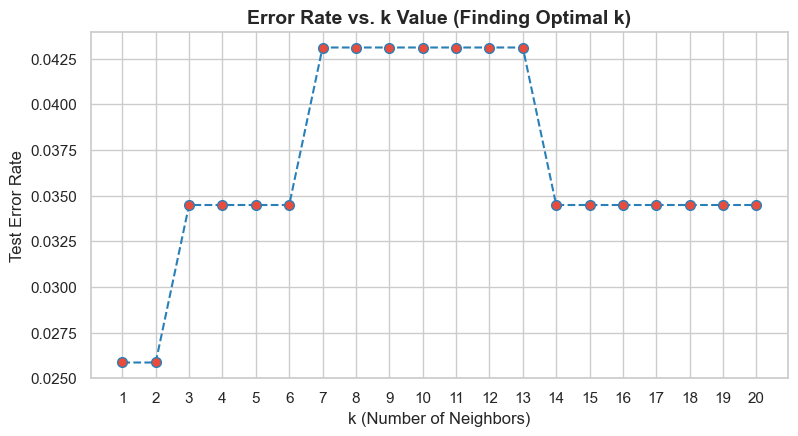

Minimum Error Rate achieved at k = 1


In [9]:
error_rates = []

for k in range(1, 21):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    pred_k = model.predict(X_test_scaled)
    error_rates.append(np.mean(pred_k != y_test))

plt.figure(figsize=(9, 4.5))
plt.plot(range(1, 21), error_rates, color='#2980b9', linestyle='dashed', marker='o',
         markerfacecolor='#e74c3c', markersize=7)
plt.title('Error Rate vs. k Value (Finding Optimal k)', fontsize=14, fontweight='bold')
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Test Error Rate', fontsize=12)
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

best_k = range(1, 21)[np.argmin(error_rates)]
print(f"Minimum Error Rate achieved at k = {best_k}")

## Key Takeaways for kNN
1. **Instance-based / Lazy**: No training parameters to optimize ($O(1)$ training, $O(N)$ inference).
2. **Metric Sensitivity**: Euclidean distance requires all numerical features to be normalized/standardized.
3. **Curse of Dimensionality**: Performance degrades quickly as the number of features increases.